# 02. Разведочный анализ данных (EDA) и целевая переменная

**Вопросы блока:**
1. Как распределена оценка клиента?
2. Где и почему есть пропуски и что с ними делать?
3. Как превратить оценку 1–5 в бинарную цель и почему порог именно такой?
4. Какие факторы (прежде всего сроки доставки) связаны с низкой оценкой?

Данные берём из витрины `order_features`, собранной SQL-запросами в ноутбуке 01
(одна строка = один доставленный заказ с отзывом).

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "data" / "olist.db"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Единая палитра: синий — основной цвет, оранжевый — «проблема» (низкая оценка / опоздание)
BLUE, ORANGE, GRAY, INK = "#2a78d6", "#eb6834", "#b5b3ad", "#52514e"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 100,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRAY, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.titleweight": "bold", "axes.titlesize": 12, "font.size": 10,
})
pd.set_option("display.max_columns", 50)


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


con = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM order_features", con, parse_dates=["order_purchase_timestamp"])
print(df.shape)

(95824, 41)


## 1. Распределение целевой переменной

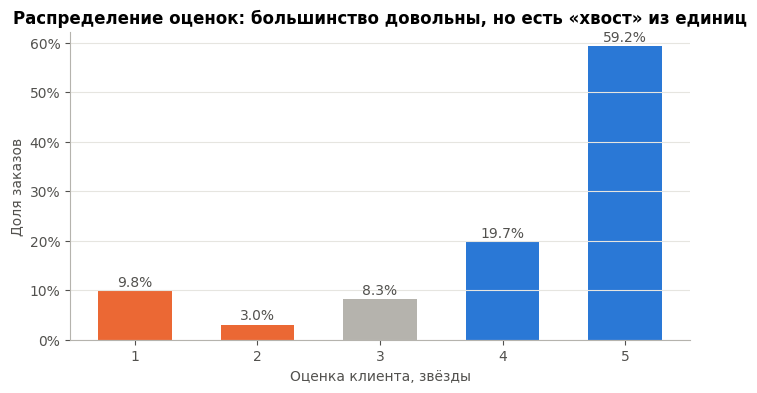

,share
review_score,
1,0.0976
2,0.0305
3,0.0826
4,0.1971
5,0.5922


In [2]:
score_share = df["review_score"].value_counts(normalize=True).sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ORANGE, ORANGE, GRAY, BLUE, BLUE]
bars = ax.bar(score_share.index.astype(str), score_share.values, color=colors, width=0.6)
for b, v in zip(bars, score_share.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.1%}", ha="center", color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Оценка клиента, звёзды")
ax.set_ylabel("Доля заказов")
ax.set_title("Распределение оценок: большинство довольны, но есть «хвост» из единиц")
save(fig, "01_target_distribution")
plt.show()
score_share.round(4).to_frame("share")

**Вывод.** Распределение сильно смещено к высоким оценкам: 59% заказов получают 5★, ещё 20% — 4★.
Низкие оценки распределены неравномерно: 1★ ставят почти 10% клиентов, а 2★ — только 3%. Недовольные клиенты
редко выбирают «середину» и чаще ставят сразу минимум. Для модели это значит, что классы будут **несбалансированы**
и accuracy не подойдёт как метрика: модель, которая всегда отвечает «всё хорошо», получит 87% точности и не найдёт ни одного недовольного клиента.

## 2. Пропущенные значения

### 2.1 Какие заказы не попали в витрину и почему

In [3]:
funnel = pd.read_sql("""
SELECT
  (SELECT COUNT(*) FROM orders)                                             AS all_orders,
  (SELECT COUNT(*) FROM orders WHERE order_status <> 'delivered')           AS not_delivered_status,
  (SELECT COUNT(*) FROM orders WHERE order_status = 'delivered'
                                 AND order_delivered_customer_date IS NULL)  AS delivered_without_date,
  (SELECT COUNT(*) FROM orders o WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND NOT EXISTS (SELECT 1 FROM order_reviews r WHERE r.order_id = o.order_id)) AS without_review,
  (SELECT COUNT(*) FROM order_features)                                     AS in_feature_mart
""", con).T.rename(columns={0: "n_orders"})
funnel

,n_orders
all_orders,99441
not_delivered_status,2963
delivered_without_date,8
without_review,646
in_feature_mart,95824


**Вывод.** Из 99 441 заказа в анализ попадает 95 824 (96,4%).
* 2 963 заказа не имеют статуса `delivered` (отменены, недоступны, ещё в пути). Мы их **исключаем сознательно**:
  бизнес-вопрос задан на момент доставки, а у этих заказов доставки не было.
* 8 «доставленных» заказов без даты доставки — техническая ошибка в данных, тоже исключены.
* 646 доставленных заказов без отзыва — у них нет целевой переменной, в обучение не идут.

### 2.2 Пропуски внутри витрины

In [4]:
missing = (df.isna().sum().to_frame("n_missing")
             .assign(pct=lambda t: (t["n_missing"] / len(df) * 100).round(2))
             .query("n_missing > 0").sort_values("n_missing", ascending=False))
missing

,n_missing,pct
seller_prior_low_rate,5816,6.07
avg_photos_qty,1324,1.38
avg_description_len,1324,1.38
customer_lng,264,0.28
customer_lat,264,0.28
seller_lng,214,0.22
seller_lat,214,0.22
total_weight_g,16,0.02
total_volume_cm3,16,0.02
seller_handling_days,15,0.02


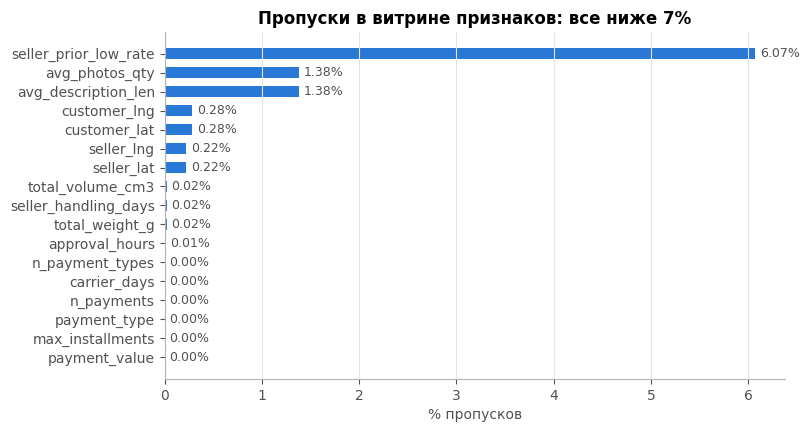

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
m = missing.sort_values("pct")
ax.barh(m.index, m["pct"], color=BLUE, height=0.6)
for y, v in enumerate(m["pct"]):
    ax.text(v + 0.05, y, f"{v:.2f}%", va="center", color=INK, fontsize=9)
ax.set_xlabel("% пропусков")
ax.set_title("Пропуски в витрине признаков: все ниже 7%")
ax.grid(axis="x", color="#e6e5e0"); ax.grid(axis="y", visible=False)
save(fig, "02_missing_values")
plt.show()

Проверим, случайны ли самые крупные пропуски: отличается ли доля низких оценок там, где значение отсутствует.

In [6]:
df["low"] = (df["review_score"] <= 2).astype(int)
check = pd.DataFrame({
    col: df.groupby(df[col].isna())["low"].mean()
    for col in ["seller_prior_low_rate", "avg_photos_qty", "customer_lat"]
}).T.rename(columns={False: "low_rate_value_present", True: "low_rate_value_missing"})
(check * 100).round(1)

,low_rate_value_present,low_rate_value_missing
seller_prior_low_rate,12.8,12.7
avg_photos_qty,12.8,16.0
customer_lat,12.8,11.7


**Вывод и решение по пропускам.**

| Признак | Причина пропуска | Решение |
|---|---|---|
| `seller_prior_low_rate` (6,1%) | новый продавец, у него ещё нет отзывов до даты покупки | заполняем медианой и добавляем флаг `is_new_seller`. Доля низких оценок у таких заказов (12,7%) почти не отличается от остальных, пропуск неинформативен |
| `avg_photos_qty`, `avg_description_len` (1,4%) | у 610 товаров нет категории и описания карточки | медиана. Заметим: у таких заказов доля 1–2★ выше (16% против 12,8%): неполная карточка товара — слабый сигнал риска, флаг сохраняем |
| координаты клиента/продавца (0,2–0,3%) | почтового префикса нет в таблице geolocation | расстояние заполняем медианой |
| вес/объём, время одобрения, платёж (<0,02%) | единичные ошибки данных | медиана / самая частая категория |

Все пропуски заполняются **внутри пайплайна модели** (`SimpleImputer`), статистика считается только на обучающей выборке, так что утечки из теста нет.

## 3. Подготовка целевой переменной: где провести порог

Нужно разбить 1–5 звёзд на «недоволен / не недоволен». Три кандидата: `≤1`, `≤2`, `≤3`.
Посмотрим, как ведут себя клиенты с разными оценками: насколько часто их заказ опаздывал,
сколько дней длилась доставка и как часто они пишут текстовую жалобу.

In [7]:
by_score = pd.read_sql("""
SELECT f.review_score,
       COUNT(*)                                    AS n_orders,
       ROUND(100.0 * AVG(f.is_late), 1)            AS pct_late,
       ROUND(AVG(f.delivery_days), 1)              AS avg_delivery_days,
       ROUND(100.0 * AVG(f.n_sellers > 1), 1)      AS pct_multi_seller,
       ROUND(100.0 * AVG(r.review_comment_message IS NOT NULL), 1) AS pct_with_text
FROM order_features f
JOIN order_reviews r ON r.order_id = f.order_id
GROUP BY f.review_score
ORDER BY f.review_score
""", con)
by_score

,review_score,n_orders,pct_late,avg_delivery_days,pct_multi_seller,pct_with_text
0,1,9415,36.6,21.3,4.8,77.3
1,2,2941,18.9,16.6,5.0,67.8
2,3,7972,8.8,14.3,2.1,43.3
3,4,18977,3.4,12.3,0.7,31.2
4,5,57048,1.9,10.7,0.7,35.8


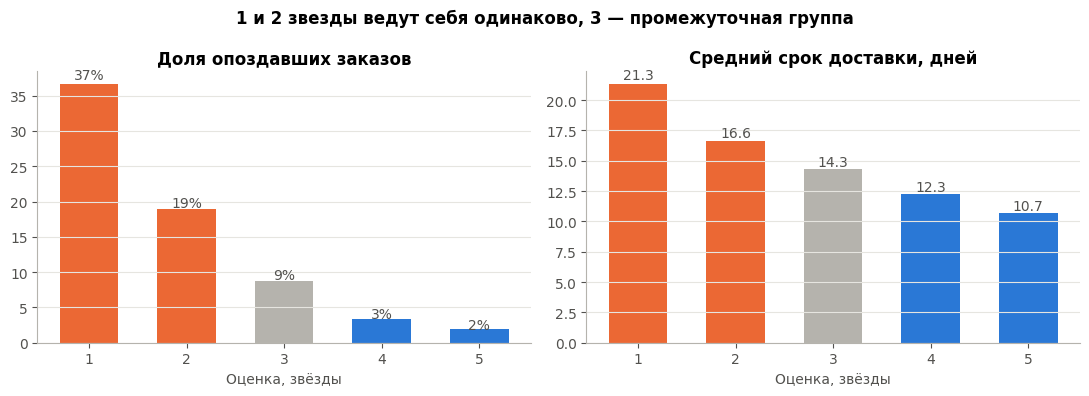

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cols = [ORANGE, ORANGE, GRAY, BLUE, BLUE]
for ax, col, title, fmt in [
    (axes[0], "pct_late", "Доля опоздавших заказов", "{:.0f}%"),
    (axes[1], "avg_delivery_days", "Средний срок доставки, дней", "{:.1f}"),
]:
    b = ax.bar(by_score["review_score"].astype(str), by_score[col], color=cols, width=0.6)
    for bar, v in zip(b, by_score[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.02, fmt.format(v), ha="center", color=INK)
    ax.set_title(title); ax.set_xlabel("Оценка, звёзды")
fig.suptitle("1 и 2 звезды ведут себя одинаково, 3 — промежуточная группа", fontweight="bold")
fig.tight_layout()
save(fig, "03_threshold_by_score")
plt.show()

In [9]:
thresholds = pd.DataFrame({
    "порог": ["≤1 звезда", "≤2 звезды", "≤3 звезды"],
    "доля положительного класса, %": [(df.review_score <= t).mean() * 100 for t in (1, 2, 3)],
}).round(1)
thresholds

,порог,"доля положительного класса, %"
0,≤1 звезда,9.8
1,≤2 звезды,12.8
2,≤3 звезды,21.1


**Выбор порога: низкая оценка = 1–2 звезды (`target = 1`), 3–5 звёзд — `target = 0`.**

Обоснование:
1. **Данные показывают естественную границу между 2 и 3 звёздами.** У клиентов с 1★ и 2★ картина похожая: частые опоздания
   (37% и 19%), долгая доставка (21 и 17 дней), больше заказов от нескольких продавцов (~5%), большинство пишет текстовую жалобу (77% и 68%).
   У 3★ показатели уже близки к довольным клиентам: 9% опозданий, 14 дней доставки, текст пишут лишь 43%.
2. **Логика бизнеса.** 1–2★ — явная жалоба, которая бьёт по рейтингу продавца и повторным покупкам.
   3★ — нейтральная оценка «нормально»: вмешиваться с компенсацией там дорого и мало что меняет.
   Такая разбивка соответствует логике NPS (detractors vs остальные).
3. **Размер класса разумный.** Порог ≤1 дал бы 9,8% положительного класса и потерял бы группу 2★ с той же природой проблем.
   Порог ≤3 (21%) смешал бы явное недовольство с нейтральными оценками, и модель училась бы на «шуме».

Итог: положительный класс — **12,8%** заказов (12 272 из 95 824), дисбаланс примерно 1:7. Это учтём при выборе метрики и весов классов.

In [10]:
df["target"] = (df["review_score"] <= 2).astype(int)
print(df["target"].value_counts())
print(f"Доля низких оценок (класс 1): {df['target'].mean():.2%}")

target
0    83552
1    12272
Name: count, dtype: int64
Доля низких оценок (класс 1): 12.81%


### Дополнительно: когда клиент ставит оценку
Olist присылает анкету, как только заказ должен быть доставлен. Проверим, успевает ли клиент оценить заказ до фактической доставки.

In [11]:
timing = pd.read_sql("""
SELECT CASE WHEN date(r.review_creation_date) < date(o.order_delivered_customer_date)
            THEN 'отзыв до фактической доставки' ELSE 'отзыв после доставки' END AS timing,
       COUNT(*) AS n,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_orders,
       ROUND(100.0 * AVG(r.review_score <= 2), 1)          AS pct_low
FROM order_features f
JOIN f_review fr     ON fr.order_id = f.order_id
JOIN order_reviews r ON r.order_id = fr.order_id AND r.review_answer_timestamp = fr.review_answer_timestamp
JOIN orders o        ON o.order_id = f.order_id
GROUP BY timing
""", con)
timing

,timing,n,pct_orders,pct_low
0,отзыв до фактической доставки,4976,5.2,72.6
1,отзыв после доставки,90848,94.8,9.5


**Важное наблюдение для бизнеса.** В 5% случаев клиент оценивает заказ **ещё до фактической доставки**, и в 73% таких случаев оценка низкая:
клиент не дождался посылки и пожаловался. Значит, модель полезно применять **не только в день доставки, но и в момент, когда заказ начинает опаздывать**.
Признаки о задержке становятся известны именно тогда.

## 4. Сроки доставки и оценка

### 4.1 Опоздание относительно обещанной даты

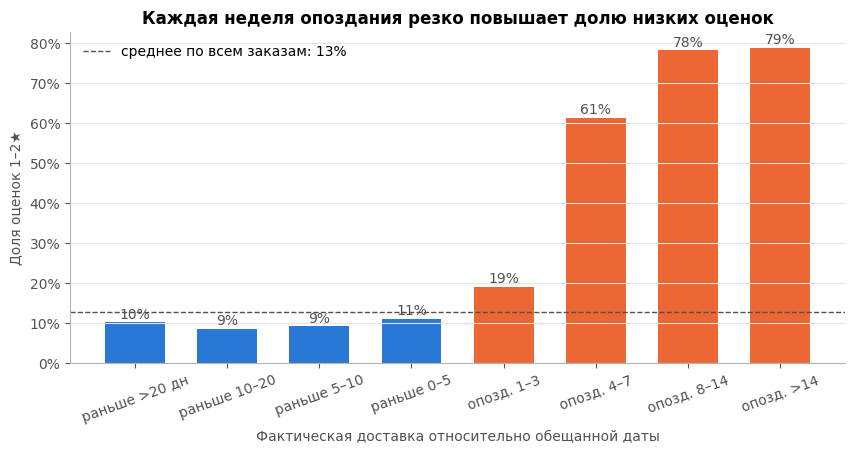

,n_orders,low_rate,avg_score
delay_bucket,,,
раньше >20 дн,13409,10.2,4.29
раньше 10–20,43496,8.6,4.33
раньше 5–10,22442,9.2,4.28
раньше 0–5,8816,11.1,4.15
опозд. 1–3,2636,19.1,3.77
опозд. 4–7,1773,61.3,2.32
опозд. 8–14,1748,78.1,1.74
опозд. >14,1504,78.8,1.71


In [12]:
bins = [-np.inf, -20, -10, -5, 0, 3, 7, 14, np.inf]
labels = ["раньше >20 дн", "раньше 10–20", "раньше 5–10", "раньше 0–5",
          "опозд. 1–3", "опозд. 4–7", "опозд. 8–14", "опозд. >14"]
df["delay_bucket"] = pd.cut(df["delay_days"], bins=bins, labels=labels)
delay_stats = df.groupby("delay_bucket", observed=True).agg(
    n_orders=("target", "size"), low_rate=("target", "mean"), avg_score=("review_score", "mean"))

fig, ax = plt.subplots(figsize=(10, 4.3))
c = [BLUE] * 4 + [ORANGE] * 4
b = ax.bar(delay_stats.index.astype(str), delay_stats["low_rate"], color=c, width=0.65)
for bar, v in zip(b, delay_stats["low_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center", color=INK)
ax.axhline(df["target"].mean(), color=INK, ls="--", lw=1, label=f"среднее по всем заказам: {df['target'].mean():.0%}")
ax.legend(frameon=False, loc="upper left")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Доля оценок 1–2★")
ax.set_xlabel("Фактическая доставка относительно обещанной даты")
ax.set_title("Каждая неделя опоздания резко повышает долю низких оценок")
plt.xticks(rotation=20)
save(fig, "04_delay_vs_low_rate")
plt.show()
delay_stats.assign(low_rate=lambda t: (t.low_rate * 100).round(1), avg_score=lambda t: t.avg_score.round(2))

**Вывод.** Это главный график проекта. Пока заказ приходит вовремя или раньше срока, доля 1–2★ стабильна: 9–11%,
и не важно, на сколько дней раньше пришла посылка. Приход раньше обещанного не «радует» клиента дополнительно.
После обещанной даты картина резко меняется: 19% при опоздании на 1–3 дня, **61% — на 4–7 дней**, 78% — больше недели.
Для бизнеса: критическое окно — **первые 3 дня опоздания**. Именно тогда стоит проактивно связаться с клиентом, пока недовольство не стало почти неизбежным.

### 4.2 Фактический срок доставки и обещанный срок

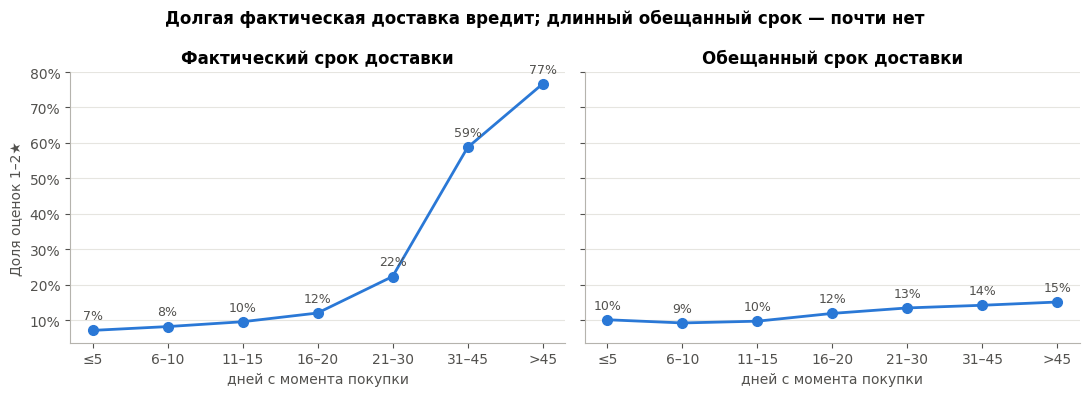

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title in [(axes[0], "delivery_days", "Фактический срок доставки"),
                       (axes[1], "estimated_days", "Обещанный срок доставки")]:
    q = pd.cut(df[col], bins=[0, 5, 10, 15, 20, 30, 45, np.inf],
               labels=["≤5", "6–10", "11–15", "16–20", "21–30", "31–45", ">45"])
    s = df.groupby(q, observed=True)["target"].mean()
    ax.plot(s.index.astype(str), s.values, marker="o", color=BLUE, lw=2, ms=7)
    for x, v in zip(s.index.astype(str), s.values):
        ax.annotate(f"{v:.0%}", (x, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color=INK)
    ax.set_title(title); ax.set_xlabel("дней с момента покупки")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylabel("Доля оценок 1–2★")
fig.suptitle("Долгая фактическая доставка вредит; длинный обещанный срок — почти нет", fontweight="bold")
fig.tight_layout()
save(fig, "05_delivery_days")
plt.show()

**Вывод.** Фактический срок доставки влияет сильно: до 15 дней доля 1–2★ почти не меняется (7–10%), после 20 дней резко растёт,
а после 30 дней превышает половину. Обещанный срок почти не влияет (10% → 15%): клиенты готовы ждать долго, **если их честно предупредили**.
Клиента расстраивает не сама долгая доставка, а нарушенное обещание. Отсюда практичный вывод: реалистичная дата доставки на витрине дешевле, чем компенсации.

### 4.3 На каком этапе теряется время: продавец или перевозчик

In [14]:
stage = pd.DataFrame({
    "продавец не уложился в срок отгрузки": df.groupby("seller_missed_limit")["target"].mean(),
}).T.rename(columns={0: "нет", 1: "да"})
print((stage * 100).round(1))
print("\nДоля заказов, где продавец опоздал с отгрузкой:", f"{df['seller_missed_limit'].mean():.1%}")
print("Медиана: продавец → перевозчик", round(df["seller_handling_days"].median(), 1),
      "дн; перевозчик → клиент", round(df["carrier_days"].median(), 1), "дн")
print("Корреляция с target: seller_handling_days =", round(df[["seller_handling_days", "target"]].corr().iloc[0, 1], 3),
      "; carrier_days =", round(df[["carrier_days", "target"]].corr().iloc[0, 1], 3))

seller_missed_limit                    нет    да
продавец не уложился в срок отгрузки  11.7  23.8

Доля заказов, где продавец опоздал с отгрузкой: 9.0%
Медиана: продавец → перевозчик 1.8 дн; перевозчик → клиент 7.1 дн
Корреляция с target: seller_handling_days = 0.143 ; carrier_days = 0.281


**Вывод.** Заметная часть времени теряется у перевозчика (медиана 7 дней против 1,8 дня у продавца), и `carrier_days` связан с недовольством
сильнее (r = 0,28 против 0,14). Но и продавцы влияют: в 9% заказов продавец не уложился в срок передачи перевозчику, и доля низких оценок у таких заказов вдвое выше (24% против 12%).
Этот сигнал известен **за несколько дней до доставки**, то есть это ранний индикатор риска.

## 5. Состав заказа

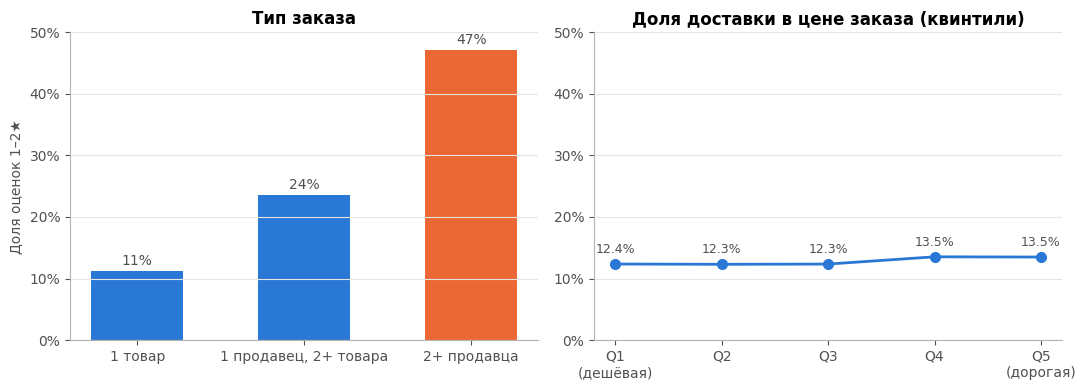

,n_orders,low_rate_%
order_type,,
1 товар,86296,11.3
"1 продавец, 2+ товара",8267,23.6
2+ продавца,1261,47.2


In [15]:
df["order_type"] = np.select(
    [df["n_sellers"] > 1, df["n_items"] > 1], ["2+ продавца", "1 продавец, 2+ товара"], "1 товар")
comp = df.groupby("order_type")["target"].agg(["size", "mean"]).sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
b = axes[0].bar(comp.index, comp["mean"], color=[BLUE, BLUE, ORANGE], width=0.55)
for bar, v in zip(b, comp["mean"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.0%}", ha="center", color=INK)
axes[0].set_title("Тип заказа"); axes[0].set_ylim(0, 0.5)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
axes[0].set_ylabel("Доля оценок 1–2★")

fr = pd.qcut(df["freight_ratio"], 5, labels=["Q1\n(дешёвая)", "Q2", "Q3", "Q4", "Q5\n(дорогая)"])
s = df.groupby(fr, observed=True)["target"].mean()
axes[1].plot(s.index.astype(str), s.values, marker="o", color=BLUE, lw=2, ms=7)
for x, v in zip(s.index.astype(str), s.values):
    axes[1].annotate(f"{v:.1%}", (x, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9, color=INK)
axes[1].set_title("Доля доставки в цене заказа (квинтили)")
axes[1].set_ylim(0, 0.5)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
fig.tight_layout()
save(fig, "06_order_composition")
plt.show()
comp.assign(mean=lambda t: (t["mean"] * 100).round(1)).rename(columns={"size": "n_orders", "mean": "low_rate_%"})

**Вывод.** Сложность заказа — второй по силе фактор после сроков. Если в заказе несколько товаров от одного продавца,
доля 1–2★ вдвое выше (24%), а если товары от **разных продавцов — в 4 раза выше (47%)**: заказ приходит несколькими посылками в разное время,
часть может потеряться или задержаться. Доля стоимости доставки в цене влияет слабо (12,3% → 13,5%): клиент соглашается с ценой доставки ещё при покупке.

## 6. Категория товара

Разброс по категориям: 8.1% – 21.9%


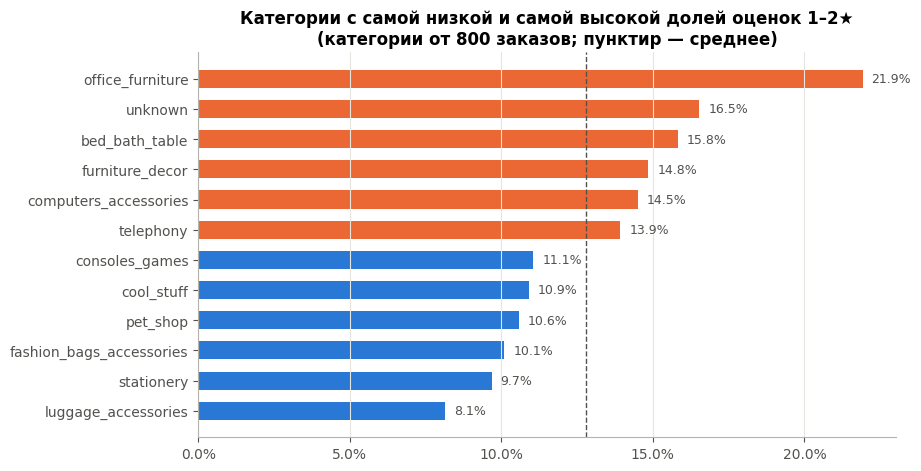

In [16]:
cat = (df.groupby("category")["target"].agg(n_orders="size", low_rate="mean")
         .query("n_orders >= 800").sort_values("low_rate"))
show = pd.concat([cat.head(6), cat.tail(6)])
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(show.index, show["low_rate"], color=[BLUE] * 6 + [ORANGE] * 6, height=0.6)
for y, v in enumerate(show["low_rate"]):
    ax.text(v + 0.003, y, f"{v:.1%}", va="center", fontsize=9, color=INK)
ax.axvline(df["target"].mean(), color=INK, ls="--", lw=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", color="#e6e5e0"); ax.grid(axis="y", visible=False)
ax.set_title("Категории с самой низкой и самой высокой долей оценок 1–2★\n(категории от 800 заказов; пунктир — среднее)")
save(fig, "07_categories")
plt.show()
print("Разброс по категориям:", f"{cat.low_rate.min():.1%} – {cat.low_rate.max():.1%}")

**Вывод.** Категория влияет умеренно: разброс от 8% до 22%. Хуже всего — офисная мебель (22%), товары для дома (bed_bath_table), мебель и декор:
крупногабаритный товар, сложная доставка, возможен брак при сборке. Высокий риск и у товаров без категории (16,5%), то есть с неполной карточкой.
Лучше всего — аксессуары, канцелярия, сумки: небольшие стандартные товары, по которым легко оправдать ожидания. Категория пригодится модели как дополнительный сигнал, но решающим фактором не является.

## 7. Продавец: опыт и репутация на момент покупки

Новые продавцы без истории отзывов: 6.1% заказов, доля 1–2★ = 12.7%


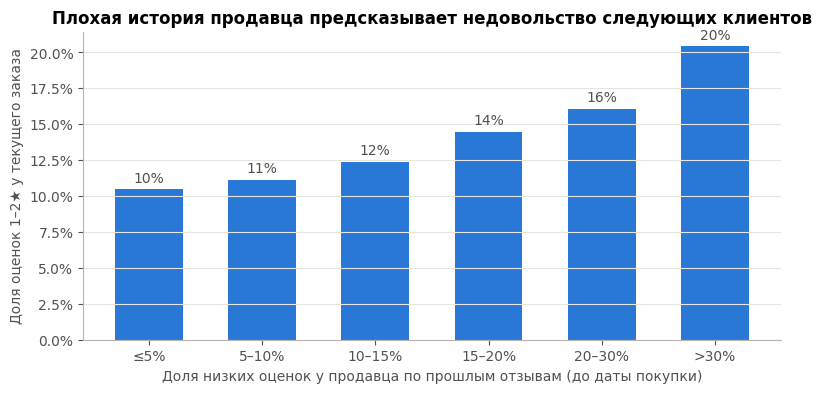

,n_orders,low_rate_%
seller_prior_low_rate,,
≤5%,17740,10.5
5–10%,19587,11.1
10–15%,24295,12.4
15–20%,16695,14.5
20–30%,7352,16.1
>30%,4339,20.4


In [17]:
rep = pd.cut(df["seller_prior_low_rate"], [-0.01, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0],
             labels=["≤5%", "5–10%", "10–15%", "15–20%", "20–30%", ">30%"])
rep_stats = df.groupby(rep, observed=True)["target"].agg(["size", "mean"])
new_seller = df.loc[df["seller_prior_low_rate"].isna(), "target"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
b = ax.bar(rep_stats.index.astype(str), rep_stats["mean"], color=BLUE, width=0.6)
for bar, v in zip(b, rep_stats["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005, f"{v:.0%}", ha="center", color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Доля низких оценок у продавца по прошлым отзывам (до даты покупки)")
ax.set_ylabel("Доля оценок 1–2★ у текущего заказа")
ax.set_title("Плохая история продавца предсказывает недовольство следующих клиентов")
save(fig, "08_seller_reputation")
plt.show()
print(f"Новые продавцы без истории отзывов: {df['seller_prior_low_rate'].isna().mean():.1%} заказов, доля 1–2★ = {new_seller:.1%}")
rep_stats.assign(mean=lambda t: (t["mean"] * 100).round(1)).rename(columns={"size": "n_orders", "mean": "low_rate_%"})

**Вывод.** История продавца работает как предиктор: если у продавца больше 30% прошлых отзывов были низкими, следующий клиент недоволен
в 20% случаев, вдвое чаще, чем у продавцов с хорошей историей (10,5%). Признак построен **без утечки**: учитываются только отзывы, оставленные до даты текущей покупки.
Новые продавцы без истории (6%) по риску не отличаются от среднего.

## 8. Оплата и география

In [18]:
pay = df.groupby("payment_type")["target"].agg(n_orders="size", low_rate="mean")
pay["low_rate"] = (pay["low_rate"] * 100).round(1)
print(pay.sort_values("n_orders", ascending=False), "\n")

inst = pd.cut(df["max_installments"], [-1, 1, 3, 6, 10, 24], labels=["1", "2–3", "4–6", "7–10", ">10"])
print((df.groupby(inst, observed=True)["target"].mean() * 100).round(1).rename("low_rate_% по числу платежей рассрочки"), "\n")

st = (df.groupby("customer_state").agg(n_orders=("target", "size"), low_rate=("target", "mean"),
                                        late_rate=("is_late", "mean"), avg_days=("delivery_days", "mean"))
        .query("n_orders >= 1000").sort_values("low_rate"))
st[["low_rate", "late_rate"]] = (st[["low_rate", "late_rate"]] * 100).round(1)
st["avg_days"] = st["avg_days"].round(1)
st

              n_orders  low_rate
payment_type                    
credit_card      72331      12.9
boleto           19062      12.5
voucher           2953      13.5
debit_card        1477      11.1 

max_installments
1       11.9
2–3     12.9
4–6     13.5
7–10    15.2
>10     19.5
Name: low_rate_% по числу платежей рассрочки, dtype: float64 



,n_orders,low_rate,late_rate,avg_days
customer_state,,,,
SP,40266,10.7,4.4,8.7
PR,4900,10.9,4.0,12.0
MG,11285,11.8,4.5,12.0
RS,5326,11.9,6.0,15.3
SC,3519,13.0,8.1,14.9
GO,1946,13.2,6.4,15.6
DF,2070,13.2,5.7,13.0
ES,1969,13.8,10.4,15.6
PE,1579,14.8,9.4,18.4


Корреляция по штатам: 0.93


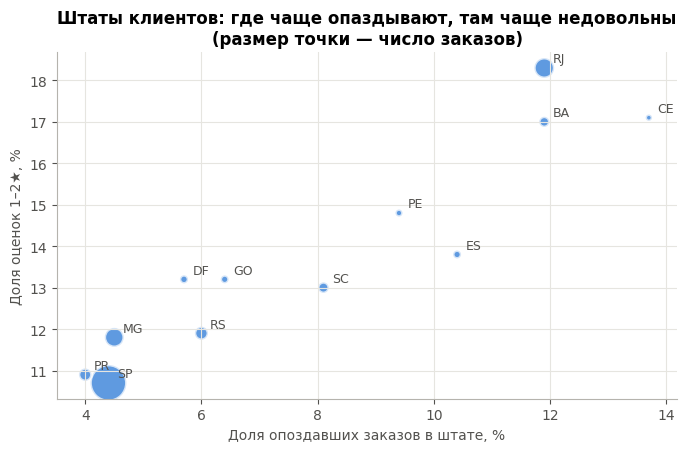

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(st["late_rate"], st["low_rate"], s=st["n_orders"] / 60, color=BLUE, alpha=0.75,
           edgecolor="white", linewidth=2)
for name, r in st.iterrows():
    ax.annotate(name, (r["late_rate"], r["low_rate"]), textcoords="offset points", xytext=(6, 4), fontsize=9, color=INK)
ax.set_xlabel("Доля опоздавших заказов в штате, %")
ax.set_ylabel("Доля оценок 1–2★, %")
ax.set_title("Штаты клиентов: где чаще опаздывают, там чаще недовольны\n(размер точки — число заказов)")
ax.grid(axis="x", color="#e6e5e0")
save(fig, "09_states")
plt.show()
print("Корреляция по штатам:", round(st[["late_rate", "low_rate"]].corr().iloc[0, 1], 2))

**Вывод.**
* **Способ оплаты почти не влияет** (11–13,5% для всех типов). Рассрочка на 10+ платежей связана с более высоким риском (19,5% против 12%),
  но это, скорее всего, отражает дорогие крупные товары, а не саму рассрочку.
* **География важна через логистику.** Клиенты в SP (где сосредоточены продавцы) получают заказ в среднем за 9 дней и недовольны в 11% случаев;
  в RJ, BA, CE — 15–21 день, 12–14% опозданий и 17–18% низких оценок. Корреляция доли опозданий и доли недовольных по штатам — 0,93.
  RJ выделяется особенно: при сопоставимом сроке доставки доля недовольных там самая высокая.

## 9. Динамика во времени

Корреляция помесячно: 0.93


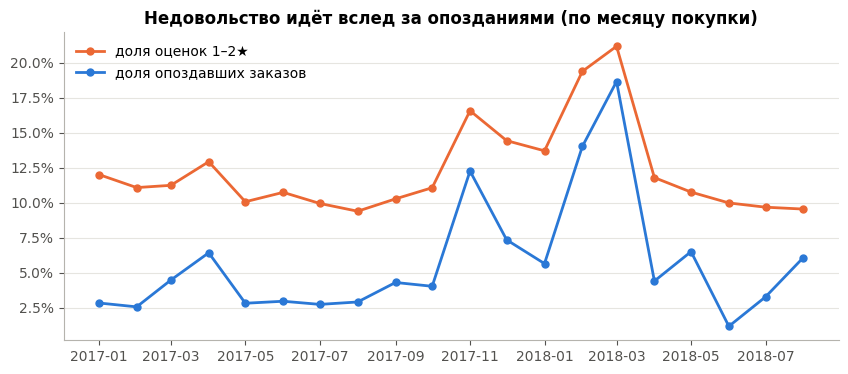

order_purchase_timestamp,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01
target,12.0,11.1,11.2,12.9,10.1,10.7,9.9,9.4,10.3,11.1,16.6,14.4,13.7,19.4,21.2,11.8,10.8,10.0,9.7,9.5
is_late,2.8,2.6,4.5,6.4,2.8,3.0,2.7,2.9,4.3,4.0,12.3,7.3,5.6,14.0,18.7,4.4,6.5,1.2,3.3,6.1


In [20]:
monthly = (df.set_index("order_purchase_timestamp")
             .resample("MS").agg({"target": "mean", "is_late": "mean", "order_id": "size"})
             .query("order_id >= 500"))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["target"], color=ORANGE, lw=2, marker="o", ms=5, label="доля оценок 1–2★")
ax.plot(monthly.index, monthly["is_late"], color=BLUE, lw=2, marker="o", ms=5, label="доля опоздавших заказов")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(frameon=False, loc="upper left")
ax.set_title("Недовольство идёт вслед за опозданиями (по месяцу покупки)")
save(fig, "10_monthly")
plt.show()
print("Корреляция помесячно:", round(monthly[["target", "is_late"]].corr().iloc[0, 1], 2))
(monthly[["target", "is_late"]] * 100).round(1).T

**Вывод.** Пики недовольства в ноябре 2017 (Black Friday) и в феврале–марте 2018 совпадают с пиками опозданий (до 19% заказов).
Помесячная корреляция — 0,93. Это ещё одно подтверждение, что **главная причина низких оценок — логистика, а не товар**.
Для моделирования важно, что доля недовольных **меняется во времени** (от 9,5% до 21%). Поэтому тестировать модель будем
на более поздних заказах (разбиение по времени), как она и работала бы в реальности.

## 10. Связь числовых признаков с целевой переменной

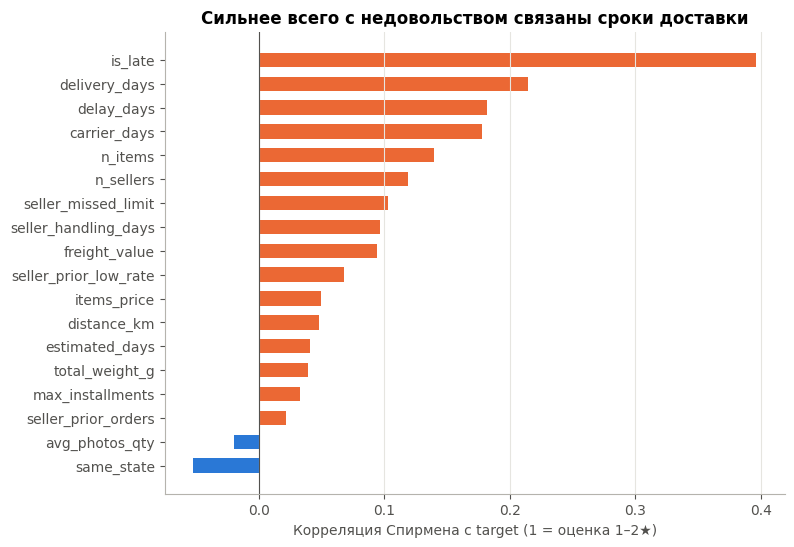

,spearman_r
same_state,-0.053
avg_photos_qty,-0.020
seller_prior_orders,0.022
max_installments,0.033
total_weight_g,0.039
estimated_days,0.041
distance_km,0.048
items_price,0.050
seller_prior_low_rate,0.068
freight_value,0.094


In [21]:
from math import radians
lat1, lon1, lat2, lon2 = (np.radians(df[c]) for c in ["customer_lat", "customer_lng", "seller_lat", "seller_lng"])
df["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(
    np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2))

num_cols = ["delay_days", "is_late", "delivery_days", "carrier_days", "seller_missed_limit", "seller_handling_days",
            "seller_prior_low_rate", "n_sellers", "n_items", "estimated_days", "distance_km", "freight_value",
            "items_price", "max_installments", "total_weight_g", "avg_photos_qty", "seller_prior_orders", "same_state"]
corr = df[num_cols + ["target"]].corr(method="spearman")["target"].drop("target").sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(corr.index, corr.values, color=[ORANGE if v > 0 else BLUE for v in corr.values], height=0.6)
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("Корреляция Спирмена с target (1 = оценка 1–2★)")
ax.set_title("Сильнее всего с недовольством связаны сроки доставки")
ax.grid(axis="x", color="#e6e5e0"); ax.grid(axis="y", visible=False)
save(fig, "11_correlations")
plt.show()
corr.round(3).to_frame("spearman_r")

**Вывод.** Лидируют признаки сроков: факт опоздания (r = 0,40), срок доставки, задержка в днях, время у перевозчика.
Затем идёт сложность заказа (число товаров и продавцов) и срыв срока отгрузки продавцом. Цена, вес, рассрочка и расстояние дают слабую связь по отдельности,
но могут помочь модели в сочетании с другими признаками. Проверим это в ноутбуке 03.

## 11. Итоги EDA

1. **Цель:** `target = 1`, если оценка 1–2★ (12,8% заказов). Порог обоснован поведением клиентов и логикой NPS. Классы несбалансированы 1:7.
2. **Пропуски** невелики (все < 7%), объяснимы и обрабатываются в пайплайне. Недоставленные заказы исключены по смыслу задачи.
3. **Главный драйвер недовольства — нарушенный срок доставки.** Опоздание на 4+ дня даёт 61–79% низких оценок против ~10% при своевременной доставке.
   Длинный, но честно обещанный срок почти не вредит.
4. **Второй драйвер — сложность заказа:** заказ от нескольких продавцов недоволен в 47% случаев.
5. **Дополнительные сигналы:** срыв отгрузки продавцом, плохая история продавца, категория (мебель), штат клиента (RJ, северо-восток).
6. **Оплата почти не важна.**
7. Доля недовольных меняется во времени вместе с опозданиями, поэтому модель проверяем на более поздних заказах.

In [22]:
con.close()